## Assignment: Xarray Fundamentals with Atmospheric Radiation Data

In [10]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)

In [11]:
import pooch
fname = pooch.retrieve(
    'http://ldeo.columbia.edu/~danielmw/CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc',
    known_hash=None,  downloader=pooch.HTTPDownloader(verify=False)
)
print(fname)

/home/wt2394/.cache/pooch/a379a4cf37bf10809e636b0809c1c88b-CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc


### 1.1 Open the dataset and display its contents

In [12]:
ds = xr.open_dataset(fname)
ds

<xarray.Dataset> Size: 737MB
Dimensions:                      (time: 203, lat: 180, lon: 360)
Coordinates:
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
Data variables: (12/14)
    toa_sw_all_mon               (time, lat, lon) float32 53MB ...
    toa_lw_all_mon               (time, lat, lon) float32 53MB ...
    toa_net_all_mon              (time, lat, lon) float32 53MB ...
    toa_sw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_lw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_net_clr_mon              (time, lat, lon) float32 53MB ...
    ...                           ...
    toa_cre_net_mon              (time, lat, lon) float32 53MB ...
    solar_mon                    (time, lat, lon) float32 53MB ...
    cldarea_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldpress_total_daynight_mon  (time, lat, lon) float32 53MB ...
    cldtemp_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldtau_total_day_mon         (time, lat, lon) float32 53MB ...
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

### 1.2 Print out the long_name attribute of each variable

In [13]:
max_name_len = max(len(var) for var in ds.variables)

for var in ds.variables:
    long_name = ds[var].attrs.get("long_name", "(no long_name)")
    print(f"{var:<{max_name_len}} : {long_name}")

toa_sw_all_mon              : Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
toa_lw_all_mon              : Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
toa_net_all_mon             : Top of The Atmosphere Net Flux, Monthly Means, All-Sky conditions
toa_sw_clr_mon              : Top of The Atmosphere Shortwave Flux, Monthly Means, Clear-Sky conditions
toa_lw_clr_mon              : Top of The Atmosphere Longwave Flux, Monthly Means, Clear-Sky conditions
toa_net_clr_mon             : Top of The Atmosphere Net Flux, Monthly Means, Clear-Sky conditions
toa_cre_sw_mon              : Top of The Atmosphere Cloud Radiative Effects Shortwave Flux, Monthly Means
toa_cre_lw_mon              : Top of The Atmosphere Cloud Radiative Effects Longwave Flux, Monthly Means
toa_cre_net_mon             : Top of The Atmosphere Cloud Radiative Effects Net Flux, Monthly Means
solar_mon                   : Incoming Solar Flux, Monthly Means
cldarea_total_daynig

### 2.1 Calculate the time-mean of the entire dataset

In [14]:
ds_mean = ds.mean(dim="time")
ds_mean

<xarray.Dataset> Size: 4MB
Dimensions:                      (lat: 180, lon: 360)
Coordinates:
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
Data variables: (12/14)
    toa_sw_all_mon               (lat, lon) float32 259kB 122.3 122.3 ... 104.4
    toa_lw_all_mon               (lat, lon) float32 259kB 141.1 141.1 ... 194.1
    toa_net_all_mon              (lat, lon) float32 259kB -91.29 ... -126.3
    toa_sw_clr_mon               (lat, lon) float32 259kB 119.9 119.9 ... 89.47
    toa_lw_clr_mon               (lat, lon) float32 259kB 140.2 140.2 ... 200.4
    toa_net_clr_mon              (lat, lon) float32 259kB -88.03 ... -117.6
    ...                           ...
    toa_cre_net_mon              (lat, lon) float32 259kB -3.253 ... -8.651
    solar_mon                    (lat, lon) float32 259kB 172.1 172.1 ... 172.3
    cldarea_total_daynight_mon   (lat, lon) float32 259kB 51.52 51.52 ... 78.93
    cldpress_total_daynight_mon  (lat, lon) float32 259kB 486.5 486.5 ... 766.9
    cldtemp_total_daynight_mon   (lat, lon) float32 259kB 225.2 225.2 ... 247.9
    cldtau_total_day_mon         (lat, lon) float32 259kB 4.158 4.158 ... 4.821

### 2.2) From this, make a 2D plot of the the time-mean Top of Atmosphere (TOA) Longwave, Shortwave, and Incoming Solar Radiation

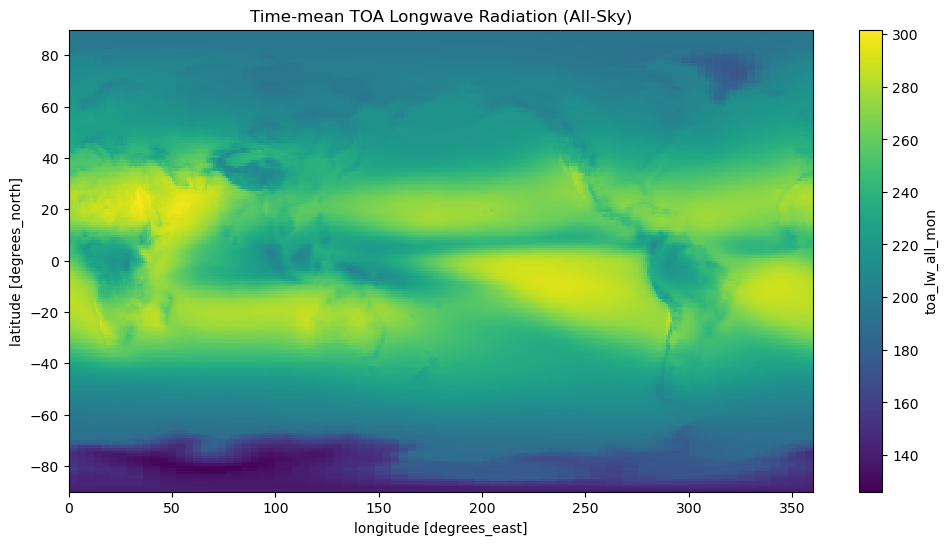

In [20]:
ds_mean["toa_lw_all_mon"].plot()
plt.title("Time-mean TOA Longwave Radiation (All-Sky)")
plt.show()

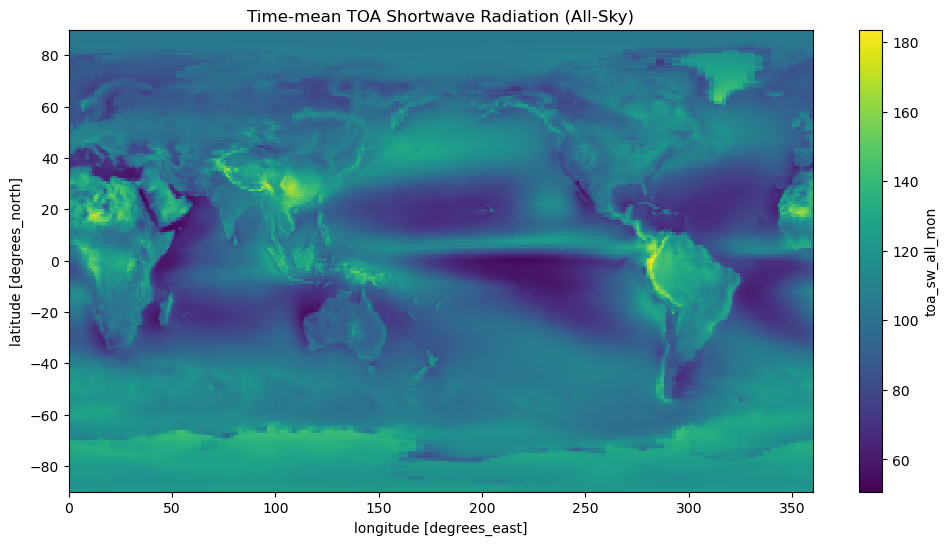

In [21]:
ds_mean["toa_sw_all_mon"].plot()
plt.title("Time-mean TOA Shortwave Radiation (All-Sky)")
plt.show()

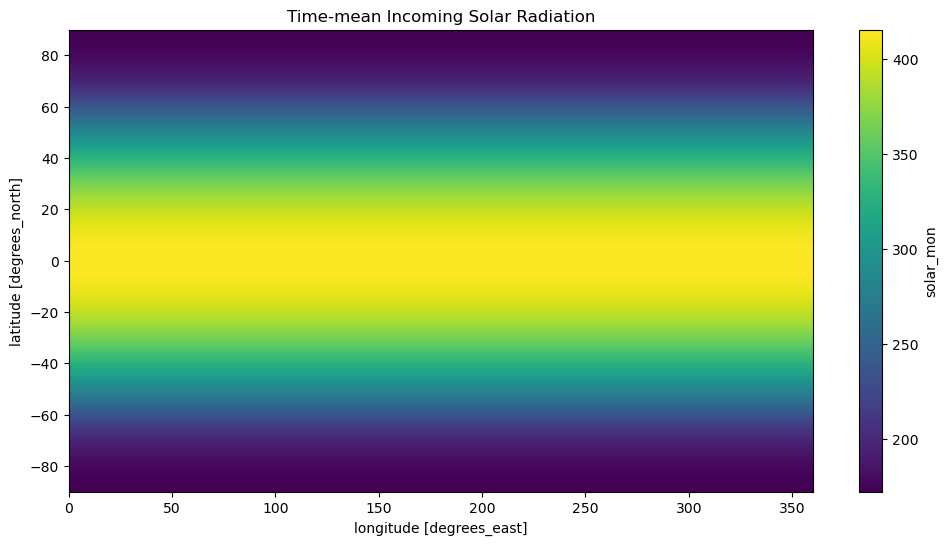

In [22]:
ds_mean["solar_mon"].plot()
plt.title("Time-mean Incoming Solar Radiation")
plt.show()

### 2.3) Add up the three variables above and verify (visually) that they are equivalent to the TOA net flux

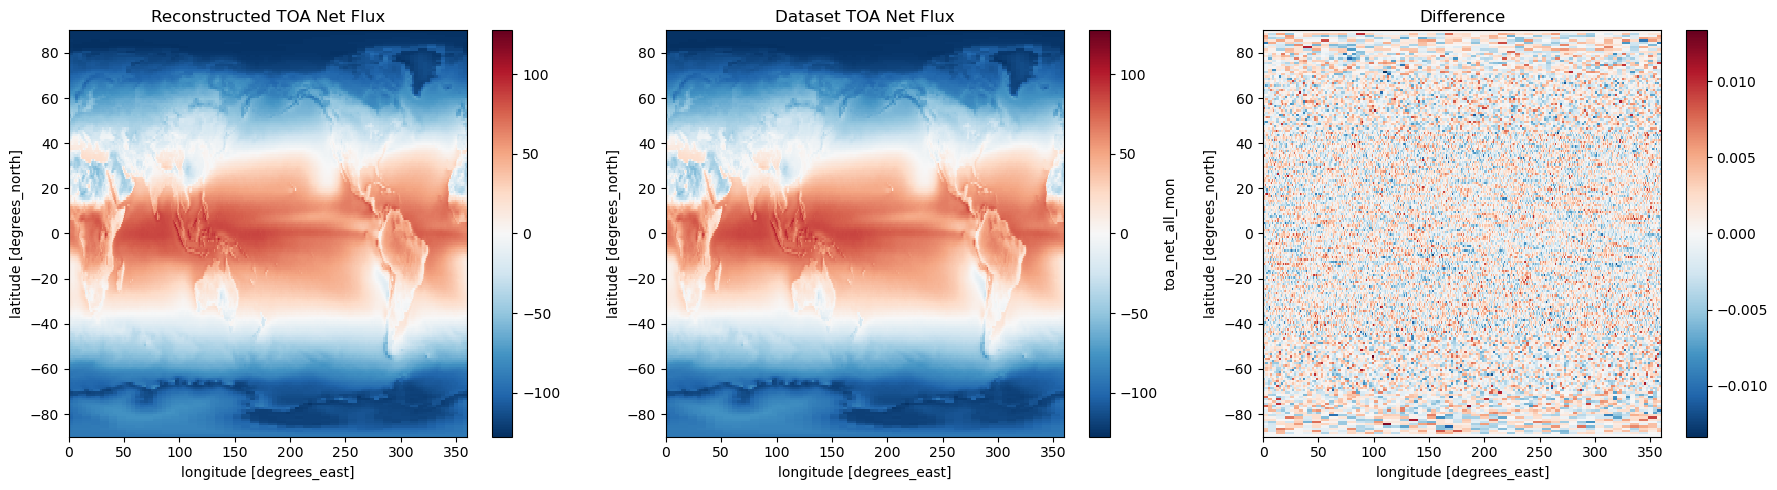

In [38]:
toa_net_calc = ds_mean["solar_mon"] - ds_mean["toa_sw_all_mon"] - ds_mean["toa_lw_all_mon"]

toa_net_true = ds_mean["toa_net_all_mon"]  

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

toa_net_calc.plot(ax=axes[0])
axes[0].set_title("Reconstructed TOA Net Flux")

toa_net_true.plot(ax=axes[1])
axes[1].set_title("Dataset TOA Net Flux")

(toa_net_calc - toa_net_true).plot(ax=axes[2])
axes[2].set_title("Difference")

plt.tight_layout()
plt.show()

### 3.1) Calculate the global (unweighted) mean of TOA net radiation

In [24]:
toa_net_global_unweighted = ds_mean["toa_net_all_mon"].mean(dim=("lat", "lon"))
toa_net_global_unweighted

<xarray.DataArray 'toa_net_all_mon' ()> Size: 4B
array(-28.729012, dtype=float32)

##### The unweighted global mean of TOA net radiation is far from zero because the latitude–longitude grid cells do not all represent equal areas on Earth’s surface. Grid cells at high latitudes cover less area than grid cells near the equator, so taking a simple arithmetic mean gives too much weight to high-latitude regions.

### 3.2) Create a weight array

In [23]:
weights = np.cos(np.deg2rad(ds_mean["lat"]))
weights

<xarray.DataArray 'lat' (lat: 180)> Size: 720B
array([0.00872656, 0.02617699, 0.04361945, 0.06104851, 0.07845908,
       0.09584576, 0.11320324, 0.13052624, 0.14780948, 0.16504757,
       0.18223551, 0.19936794, 0.21643965, 0.23344542, 0.25037998,
       0.26723838, 0.28401536, 0.30070582, 0.3173047 , 0.33380693,
       0.35020736, 0.3665012 , 0.38268346, 0.3987491 , 0.4146933 ,
       0.43051115, 0.44619778, 0.4617486 , 0.47715878, 0.49242356,
       0.5075384 , 0.5224986 , 0.5372996 , 0.551937  , 0.56640625,
       0.58070296, 0.59482276, 0.6087614 , 0.62251467, 0.6360782 ,
       0.64944804, 0.66262007, 0.67559016, 0.68835455, 0.70090926,
       0.71325046, 0.72537434, 0.7372773 , 0.7489557 , 0.76040596,
       0.77162457, 0.78260815, 0.7933533 , 0.8038569 , 0.8141155 ,
       0.8241262 , 0.83388585, 0.8433914 , 0.85264015, 0.8616291 ,
       0.87035567, 0.87881714, 0.8870108 , 0.89493436, 0.90258527,
       0.9099613 , 0.9170601 , 0.9238795 , 0.9304176 , 0.9366722 ,
       0.9426415 , 0.94832367, 0.95371693, 0.95881975, 0.96363044,
       0.96814764, 0.9723699 , 0.976296  , 0.9799247 , 0.9832549 ,
       0.9862856 , 0.9890159 , 0.9914449 , 0.9935719 , 0.9953962 ,
       0.9969173 , 0.9981348 , 0.99904823, 0.99965733, 0.9999619 ,
       0.9999619 , 0.99965733, 0.99904823, 0.9981348 , 0.9969173 ,
       0.9953962 , 0.9935719 , 0.9914449 , 0.9890159 , 0.9862856 ,
       0.9832549 , 0.9799247 , 0.976296  , 0.9723699 , 0.96814764,
       0.96363044, 0.95881975, 0.95371693, 0.94832367, 0.9426415 ,
       0.9366722 , 0.9304176 , 0.9238795 , 0.9170601 , 0.9099613 ,
       0.90258527, 0.89493436, 0.8870108 , 0.87881714, 0.87035567,
       0.8616291 , 0.85264015, 0.8433914 , 0.83388585, 0.8241262 ,
       0.8141155 , 0.8038569 , 0.7933533 , 0.78260815, 0.77162457,
       0.76040596, 0.7489557 , 0.7372773 , 0.72537434, 0.71325046,
       0.70090926, 0.68835455, 0.67559016, 0.66262007, 0.64944804,
       0.6360782 , 0.62251467, 0.6087614 , 0.59482276, 0.58070296,
       0.56640625, 0.551937  , 0.5372996 , 0.5224986 , 0.5075384 ,
       0.49242356, 0.47715878, 0.4617486 , 0.44619778, 0.43051115,
       0.4146933 , 0.3987491 , 0.38268346, 0.3665012 , 0.35020736,
       0.33380693, 0.3173047 , 0.30070582, 0.28401536, 0.26723838,
       0.25037998, 0.23344542, 0.21643965, 0.19936794, 0.18223551,
       0.16504757, 0.14780948, 0.13052624, 0.11320324, 0.09584576,
       0.07845908, 0.06104851, 0.04361945, 0.02617699, 0.00872656],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Attributes:
    long_name:      latitude
    standard_name:  latitude
    units:          degrees_north
    valid_range:    [-90.  90.]

### 3.3) Redo your global mean TOA net radiation calculation with this weight factor

In [25]:
toa_net_global_weighted = ds_mean["toa_net_all_mon"].weighted(weights).mean(dim=("lat", "lon"))
toa_net_global_weighted

<xarray.DataArray 'toa_net_all_mon' ()> Size: 4B
array(0.8780864, dtype=float32)

##### Using latitude weights proportional to cos(latitude), the weighted global mean TOA net radiation is about 0.88 W/m², which is much closer to zero than the unweighted mean. This makes more physical sense because latitude–longitude grid cells do not all represent equal areas, so the weighted mean gives a more accurate global average. The result is also in the right general range for Earth’s current energy imbalance, which is estimated to be around 0.5–1.0 W/m², although this simple calculation is better understood as an approximation than a precise detection.

### 3.4) Now that you have a weight factor, verify that the TOA incoming solar, outgoing longwave, and outgoing shortwave approximately match up with infographic shown in the first cell of this assignment

In [26]:
solar_global = ds_mean["solar_mon"].weighted(weights).mean(dim=("lat", "lon"))
lw_global    = ds_mean["toa_lw_all_mon"].weighted(weights).mean(dim=("lat", "lon"))
sw_global    = ds_mean["toa_sw_all_mon"].weighted(weights).mean(dim=("lat", "lon"))

print("Incoming solar radiation =", float(solar_global.values))
print("Outgoing longwave radiation =", float(lw_global.values))
print("Outgoing shortwave radiation =", float(sw_global.values))

Incoming solar radiation = 340.2835388183594
Outgoing longwave radiation = 240.26669311523438
Outgoing shortwave radiation = 99.13859558105469


##### The weighted global means are approximately consistent with the NASA energy budget infographic: incoming solar is about 340 W/m², outgoing longwave is about 240 W/m², and outgoing shortwave is about 99 W/m². Any small differences are expected because the CERES subset and averaging period used here are not identical to those used in the infographic.

### 4.1) calculate the pixel area using this formula and create a 2D (lon, lat) DataArray for it

In [27]:
# Earth's radius in meters
R = 6.371e6

# grid spacing in radians
dlat = np.deg2rad(float(ds_mean["lat"][1] - ds_mean["lat"][0]))
dlon = np.deg2rad(float(ds_mean["lon"][1] - ds_mean["lon"][0]))

# latitude in radians
lat_rad = np.deg2rad(ds_mean["lat"])

# 2D pixel area DataArray with dimensions (lat, lon)
area = (R**2) * np.cos(lat_rad) * dlat * dlon * xr.ones_like(ds_mean["toa_net_all_mon"])

area

<xarray.DataArray (lat: 180, lon: 360)> Size: 259kB
array([[1.0789794e+08, 1.0789794e+08, 1.0789794e+08, ..., 1.0789794e+08,
        1.0789794e+08, 1.0789794e+08],
       [3.2366051e+08, 3.2366051e+08, 3.2366051e+08, ..., 3.2366051e+08,
        3.2366051e+08, 3.2366051e+08],
       [5.3932454e+08, 5.3932454e+08, 5.3932454e+08, ..., 5.3932454e+08,
        5.3932454e+08, 5.3932454e+08],
       ...,
       [5.3932454e+08, 5.3932454e+08, 5.3932454e+08, ..., 5.3932454e+08,
        5.3932454e+08, 5.3932454e+08],
       [3.2366051e+08, 3.2366051e+08, 3.2366051e+08, ..., 3.2366051e+08,
        3.2366051e+08, 3.2366051e+08],
       [1.0789794e+08, 1.0789794e+08, 1.0789794e+08, ..., 1.0789794e+08,
        1.0789794e+08, 1.0789794e+08]], dtype=float32)
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

In [28]:
total_area_pixels = area.sum(dim=("lat", "lon"))
earth_surface_area = 4 * np.pi * R**2

print("Sum of pixel areas =", float(total_area_pixels.values))
print("Earth surface area =", earth_surface_area)
print("Difference =", float(total_area_pixels.values - earth_surface_area))
print("Relative error =", float((total_area_pixels.values - earth_surface_area) / earth_surface_area))

Sum of pixel areas = 510070953607168.0
Earth surface area = 510064471909788.25
Difference = 6481697379.75
Relative error = 1.27076041102827e-05


### 4.2) Calculate and plot the total amount of net radiation in each 1-degree latitude band

In [29]:
# total net radiation in each pixel (W)
net_radiation_pixel = ds_mean["toa_net_all_mon"] * area

# total net radiation in each 1-degree latitude band (W)
net_radiation_latband = net_radiation_pixel.sum(dim="lon")

net_radiation_latband

<xarray.DataArray (lat: 180)> Size: 720B
array([-3.54590969e+12, -1.06014788e+13, -1.80170816e+13, -2.57573257e+13,
       -3.40753646e+13, -4.28641301e+13, -5.13862722e+13, -5.96590838e+13,
       -6.78448259e+13, -7.54497995e+13, -8.31853796e+13, -9.05219219e+13,
       -9.70055777e+13, -1.04934289e+14, -1.14619817e+14, -1.23338291e+14,
       -1.31964070e+14, -1.42516175e+14, -1.53246312e+14, -1.62030560e+14,
       -1.69189080e+14, -1.76487689e+14, -1.82780487e+14, -1.84844856e+14,
       -1.84175278e+14, -1.82979431e+14, -1.79744180e+14, -1.77398323e+14,
       -1.75145008e+14, -1.72413476e+14, -1.66473771e+14, -1.62332433e+14,
       -1.58036107e+14, -1.53721611e+14, -1.49651324e+14, -1.45160516e+14,
       -1.39039324e+14, -1.33985196e+14, -1.28509247e+14, -1.22199051e+14,
       -1.16206036e+14, -1.09613723e+14, -1.01964789e+14, -9.37615017e+13,
       -8.49667592e+13, -7.64734446e+13, -6.70239168e+13, -5.72005422e+13,
       -4.71600831e+13, -3.68998928e+13, -2.67240625e+13, -1.71012260e+13,
       -6.17564288e+12,  5.96529381e+12,  1.68845032e+13,  2.63153821e+13,
        3.51119826e+13,  4.49692303e+13,  5.22451943e+13,  6.03060888e+13,
        6.85861440e+13,  7.59660429e+13,  8.36732107e+13,  9.19149342e+13,
        9.97606818e+13,  1.05551892e+14,  1.12840132e+14,  1.19949268e+14,
        1.27713059e+14,  1.36137058e+14,  1.46905212e+14,  1.56408213e+14,
        1.65012509e+14,  1.75317646e+14,  1.87106895e+14,  1.98256395e+14,
        2.09196801e+14,  2.19159028e+14,  2.30510291e+14,  2.40931224e+14,
...
        2.16284285e+14,  1.93760974e+14,  1.74417749e+14,  1.54374865e+14,
        1.35124117e+14,  1.22776506e+14,  1.12934957e+14,  1.02644366e+14,
        9.28939686e+13,  8.42323030e+13,  7.53602847e+13,  6.44833975e+13,
        5.57948925e+13,  4.22197676e+13,  3.56620278e+13,  2.93768046e+13,
        2.19258919e+13,  2.33764563e+13,  2.18753841e+13,  1.93237436e+13,
        1.26201983e+13,  4.92340091e+12, -2.31638145e+12, -1.20533528e+13,
       -2.26329698e+13, -3.43087063e+13, -4.42935951e+13, -5.29803678e+13,
       -6.20347628e+13, -7.26829430e+13, -8.18680326e+13, -9.03121899e+13,
       -9.84623518e+13, -1.06768072e+14, -1.14103591e+14, -1.19534359e+14,
       -1.25045473e+14, -1.30817985e+14, -1.35595330e+14, -1.39364189e+14,
       -1.42507501e+14, -1.46298733e+14, -1.50736072e+14, -1.52816111e+14,
       -1.53193229e+14, -1.54113459e+14, -1.58312545e+14, -1.59915591e+14,
       -1.59964346e+14, -1.59674670e+14, -1.59833953e+14, -1.60285562e+14,
       -1.58478421e+14, -1.57355371e+14, -1.56079179e+14, -1.54075040e+14,
       -1.51029136e+14, -1.48480694e+14, -1.45203080e+14, -1.40208377e+14,
       -1.34208316e+14, -1.27355050e+14, -1.20557526e+14, -1.13381399e+14,
       -1.05991245e+14, -9.75691412e+13, -8.90332963e+13, -7.99774920e+13,
       -7.14594813e+13, -6.28547283e+13, -5.34981714e+13, -4.38574546e+13,
       -3.41336360e+13, -2.44312630e+13, -1.46783632e+13, -4.90453021e+12],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5

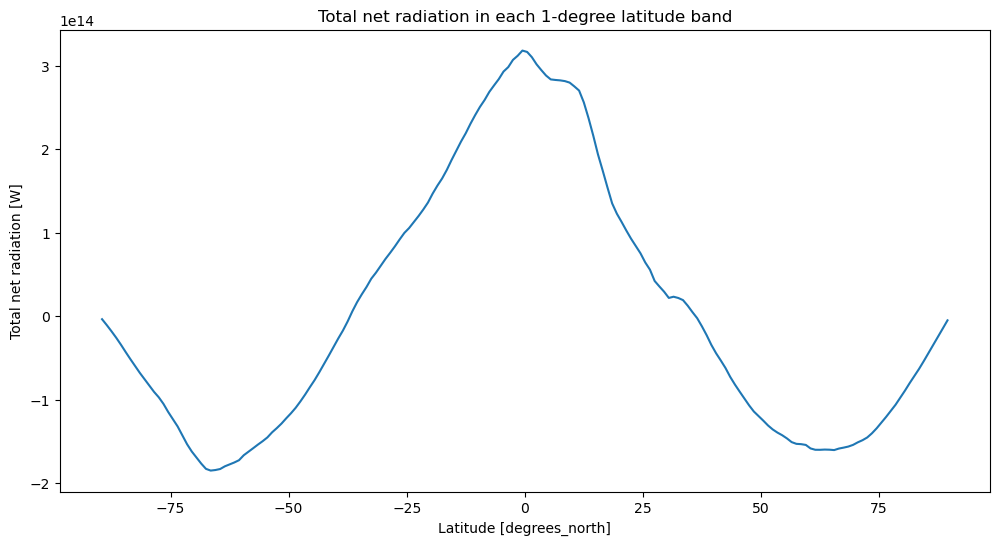

In [30]:
plt.plot(ds_mean["lat"], net_radiation_latband)
plt.xlabel("Latitude [degrees_north]")
plt.ylabel("Total net radiation [W]")
plt.title("Total net radiation in each 1-degree latitude band")
plt.show()

### 4.3) Plot the cumulative sum of the total amount of net radiation as a function of latitude

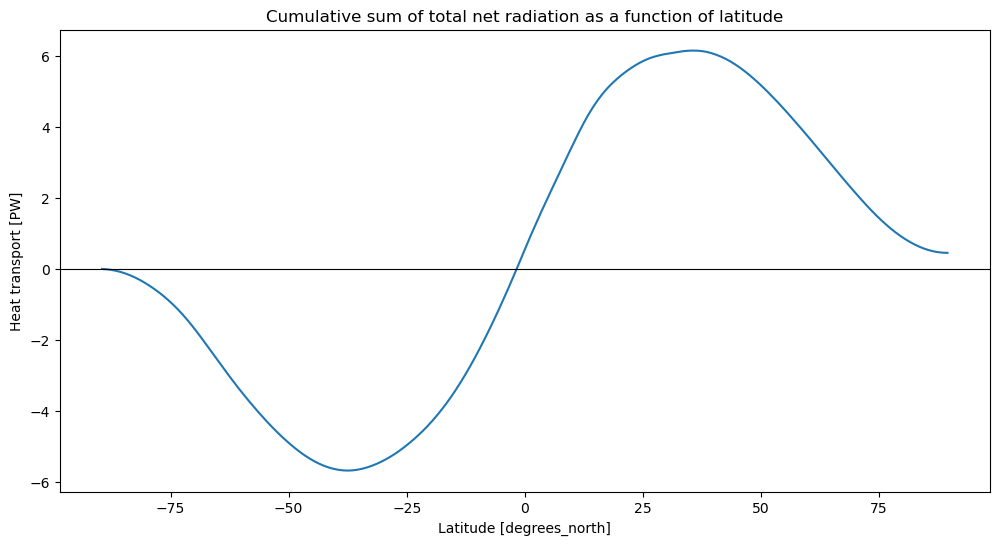

In [31]:
# cumulative sum of total net radiation by latitude band
heat_transport = net_radiation_latband.cumsum(dim="lat")

# convert from W to PW for plotting
heat_transport_pw = heat_transport / 1e15

heat_transport_pw.plot()
plt.xlabel("Latitude [degrees_north]")
plt.ylabel("Heat transport [PW]")
plt.title("Cumulative sum of total net radiation as a function of latitude")
plt.axhline(0, color="k", linewidth=0.8)
plt.show()

### 5.2) Antarctic Sea Ice

In [32]:
%pip install netCDF4 h5netcdf

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [33]:
import xarray as xr
import pooch
url = 'https://polarwatch.noaa.gov/erddap/files/nsidcCDRiceSQsh1day/2017/seaice_conc_daily_sh_f17_20170807_v03r01.nc'
fname = pooch.retrieve(url, known_hash='19b74e7e97f1c0786da0c674c4d5e4af0da5b32e2fe8c66a8f1a8a9a1241e73c')
ds_ice = xr.open_dataset(fname, drop_variables='melt_onset_day_seaice_conc_cdr')

In [34]:
ds_ice.data_vars

Data variables:
    projection                  |S1 1B ...
    seaice_conc_cdr             (time, ygrid, xgrid) float32 420kB ...
    stdev_of_seaice_conc_cdr    (time, ygrid, xgrid) float32 420kB ...
    qa_of_seaice_conc_cdr       (time, ygrid, xgrid) float32 420kB ...
    goddard_merged_seaice_conc  (time, ygrid, xgrid) float32 420kB ...
    goddard_nt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
    goddard_bt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...

In [35]:
ice = ds_ice["seaice_conc_cdr"].sel(time="2017-08-07")
ice

<xarray.DataArray 'seaice_conc_cdr' (time: 1, ygrid: 332, xgrid: 316)> Size: 420kB
[104912 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 8B 2017-08-07T12:00:00
  * ygrid      (ygrid) float32 1kB 4.338e+06 4.312e+06 ... -3.912e+06 -3.938e+06
  * xgrid      (xgrid) float32 1kB -3.938e+06 -3.912e+06 ... 3.912e+06 3.938e+06
    latitude   (ygrid, xgrid) float64 839kB ...
    longitude  (ygrid, xgrid) float64 839kB ...
Attributes: (12/13)
    valid_range:            [  0 100]
    long_name:              NOAA/NSIDC Climate Data Record of Passive Microwa...
    standard_name:          sea_ice_area_fraction
    units:                  1
    flag_values:            [-5 -4 -3 -2 -1]
    flag_meanings:          pole_hole lakes coastal land_mask missing_data
    ...                     ...
    grid_mapping:           projection
    reference:              https://nsidc.org/api/dataset/metadata/v2/oai?ver...
    ancillary_variables:    stdev_of_seaice_conc_cdr qa_of_seaice_conc_cdr
    cell_methods:           time: mean (interval: 1 day)
    coverage_content_type:  physicalMeasurement
    ioos_category:          Ice Distribution

In [36]:
ice = ds_ice["seaice_conc_cdr"].sel(time="2017-08-07").squeeze()
ice

<xarray.DataArray 'seaice_conc_cdr' (ygrid: 332, xgrid: 316)> Size: 420kB
[104912 values with dtype=float32]
Coordinates:
  * ygrid      (ygrid) float32 1kB 4.338e+06 4.312e+06 ... -3.912e+06 -3.938e+06
  * xgrid      (xgrid) float32 1kB -3.938e+06 -3.912e+06 ... 3.912e+06 3.938e+06
    time       datetime64[ns] 8B 2017-08-07T12:00:00
    latitude   (ygrid, xgrid) float64 839kB ...
    longitude  (ygrid, xgrid) float64 839kB ...
Attributes: (12/13)
    valid_range:            [  0 100]
    long_name:              NOAA/NSIDC Climate Data Record of Passive Microwa...
    standard_name:          sea_ice_area_fraction
    units:                  1
    flag_values:            [-5 -4 -3 -2 -1]
    flag_meanings:          pole_hole lakes coastal land_mask missing_data
    ...                     ...
    grid_mapping:           projection
    reference:              https://nsidc.org/api/dataset/metadata/v2/oai?ver...
    ancillary_variables:    stdev_of_seaice_conc_cdr qa_of_seaice_conc_cdr
    cell_methods:           time: mean (interval: 1 day)
    coverage_content_type:  physicalMeasurement
    ioos_category:          Ice Distribution

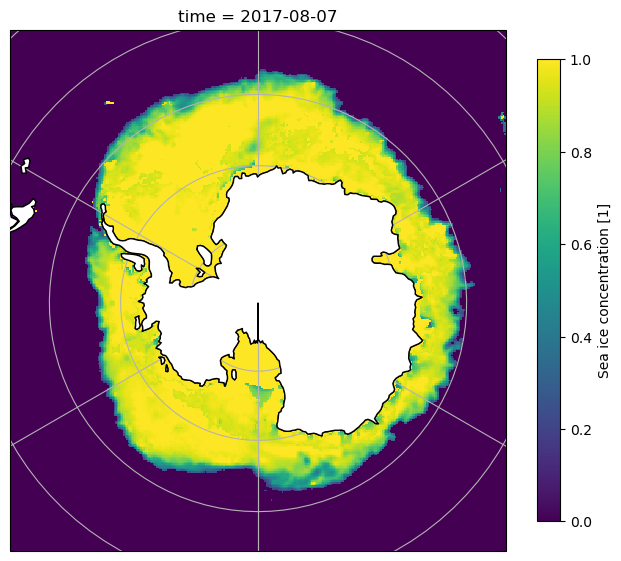

In [37]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ice = ds_ice["seaice_conc_cdr"].sel(time="2017-08-07").squeeze()

proj = ccrs.Stereographic(
    central_latitude=-90,
    central_longitude=0,
    true_scale_latitude=-70
)

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=proj)

pcm = ax.pcolormesh(
    ice["xgrid"],
    ice["ygrid"],
    ice,
    transform=proj,
    cmap="viridis",
    vmin=0,
    vmax=1,
    shading="auto"
)
ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black', zorder=3)
ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor="white")
ax.gridlines(color="0.7")

cbar = plt.colorbar(pcm, ax=ax, shrink=0.75)
cbar.set_label("Sea ice concentration [1]")

plt.title("time = 2017-08-07")
plt.show()

### 5.3) Global USGS Earthquakes

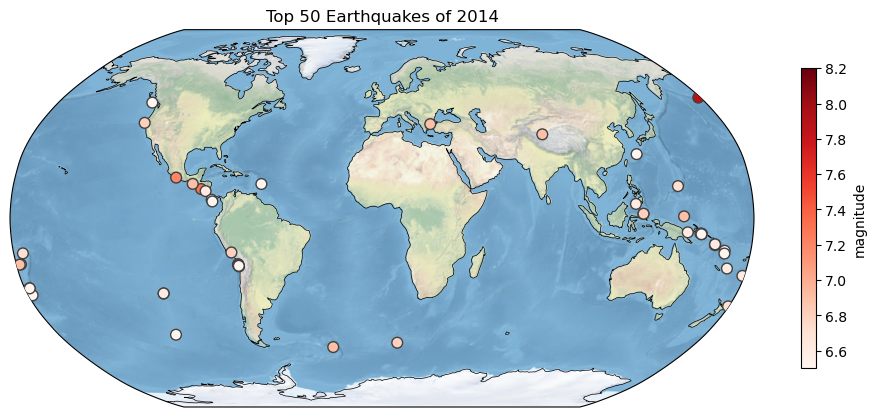

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

url = "http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv"

eq = pd.read_csv(url)

top50 = eq.nlargest(50, "mag")

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())

ax.set_global()
ax.stock_img()      
ax.coastlines(linewidth=0.5)

sc = ax.scatter(
    top50["longitude"],
    top50["latitude"],
    c=top50["mag"],
    cmap="Reds",
    s=60,
    edgecolor="0.25",
    linewidth=1,
    transform=ccrs.PlateCarree(),
    zorder=5,
    vmin=6.5,
    vmax=8.2
)
plt.title("Top 50 Earthquakes of 2014")

cbar = plt.colorbar(sc, ax=ax, shrink=0.65, pad=0.05)
cbar.set_label("magnitude")

plt.show()